In [34]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, clear_output
import time

state = [cosθ1, sinθ1, cosθ2, sinθ2, θ̇1, θ̇2]  
total number of states = 10^6  
actions = { -1 torque, 0 torque, +1 torque }  
Q-table size = (10^6) * 3


function to discretize state  
action funciton to apply torque  
sarsa and q learning func (Q = Q + alpha*(r + gamma*Q' - Q))  
policy - epsilon greedy (known state and action decided based on best Q)

In [5]:
def discretize(obs, bins):
    return tuple(
        np.digitize(obs[i], bins[i])
        for i in range(len(obs))
    )

def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(3)
    return np.argmax(Q[state])

In [9]:
num_bins = 10
gamma = 0.99
episodes=5000
alpha=0.1
epsilon_start=1.0
epsilon_min=0.01
epsilon_decay=0.995
max_steps=500

In [10]:
bins = []
    
# cos and sin ∈ [-1,1]
for _ in range(4):
    bins.append(np.linspace(-1, 1, num_bins - 1))

# velocities (use env limits)
bins.append(np.linspace(-4*np.pi, 4*np.pi, num_bins - 1))
bins.append(np.linspace(-9*np.pi, 9*np.pi, num_bins - 1))
bins

[array([-1.  , -0.75, -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ]),
 array([-1.  , -0.75, -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ]),
 array([-1.  , -0.75, -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ]),
 array([-1.  , -0.75, -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ]),
 array([-12.56637061,  -9.42477796,  -6.28318531,  -3.14159265,
          0.        ,   3.14159265,   6.28318531,   9.42477796,
         12.56637061]),
 array([-28.27433388, -21.20575041, -14.13716694,  -7.06858347,
          0.        ,   7.06858347,  14.13716694,  21.20575041,
         28.27433388])]

In [37]:
def plot_returns(returns):
    label = None
    plt.figure()

    plt.plot(returns)

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Return vs Episode")

    if label is not None:
        plt.legend()

    plt.grid(True)
    plt.show()

In [42]:
def visualize_policy(Q, episodes=3, max_steps=500):
    env = gym.make("Acrobot-v1", render_mode="human")

    for _ in range(episodes):
        obs, _ = env.reset()
        state = discretize(obs, bins)

        for _ in range(max_steps):

            # Greedy action (no exploration)
            action = np.argmax(Q[state])

            obs, _, terminated, truncated, _ = env.step(action)
            state = discretize(obs, bins)

            if terminated or truncated:
                break

    env.close()

def visualize_policy_notebook(Q, episodes=3, max_steps=500):
        
    envs = [gym.make("Acrobot-v1", render_mode="rgb_array") 
            for _ in range(episodes)]
    
    states = []
    dones = [False] * episodes
    
    # reset all envs
    for env in envs:
        obs, _ = env.reset()
        states.append(discretize(obs, bins))

    for _ in range(max_steps):

        frames = []

        for i in range(episodes):
            if not dones[i]:
                action = np.argmax(Q[states[i]])
                obs, _, terminated, truncated, _ = envs[i].step(action)
                states[i] = discretize(obs, bins)
                dones[i] = terminated or truncated

            frames.append(envs[i].render())

        clear_output(wait=True)

        fig, axes = plt.subplots(1, episodes, figsize=(5*episodes, 4))
        if episodes == 1:
            axes = [axes]

        for ax, frame in zip(axes, frames):
            ax.imshow(frame)
            ax.axis("off")

        plt.show()
        time.sleep(0.02)

        if all(dones):
            break

    for env in envs:
        env.close()

In [ ]:
def sarsa():
    env = gym.make("Acrobot-v1")

    # Q-table: 10^6 states × 3 actions
    Q = np.zeros((num_bins,)*6 + (3,), dtype=np.float32)

    returns = []
    epsilon = epsilon_start

    for ep in range(episodes):

        obs, _ = env.reset()
        state = discretize(obs, bins)

        action = epsilon_greedy(Q, state, epsilon)

        total_reward = 0

        for _ in range(max_steps):

            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_next = discretize(obs_next, bins)
            action_next = epsilon_greedy(Q, state_next, epsilon)

            # SARSA update
            Q[state][action] += alpha * (reward + gamma * Q[state_next][action_next] - Q[state][action])

            state = state_next
            action = action_next
            total_reward += reward

            if done:
                break

        returns.append(total_reward)

        # epsilon decay
        # epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if ep % 250 == 0:
            print("Episode: ", ep)

    env.close()
    return Q, returns

In [ ]:
Q_sarsa, returns_sarsa = sarsa()

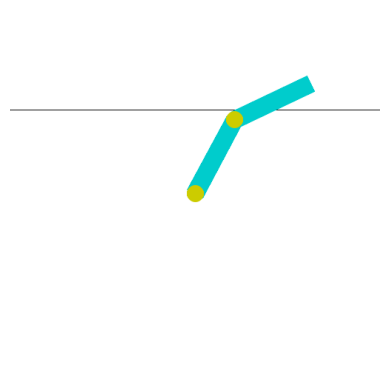

In [31]:
visualize_policy_notebook(Q_sarsa, bins)

In [ ]:
def sarsa_decay():
    env = gym.make("Acrobot-v1")

    # Q-table: 10^6 states × 3 actions
    Q = np.zeros((num_bins,)*6 + (3,), dtype=np.float32)

    returns = []
    epsilon = epsilon_start

    for ep in range(episodes):

        obs, _ = env.reset()
        state = discretize(obs, bins)

        action = epsilon_greedy(Q, state, epsilon)

        total_reward = 0

        for _ in range(max_steps):

            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_next = discretize(obs_next, bins)
            action_next = epsilon_greedy(Q, state_next, epsilon)

            # SARSA update
            Q[state][action] += alpha * (reward + gamma * Q[state_next][action_next] - Q[state][action])

            state = state_next
            action = action_next
            total_reward += reward

            if done:
                break

        returns.append(total_reward)

        # epsilon decay
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if ep % 500 == 0:
            print("Episode: ", ep)

    env.close()
    return Q, returns

In [ ]:
Q_sarsa_decay, returns_sarsa_decay = sarsa_decay()

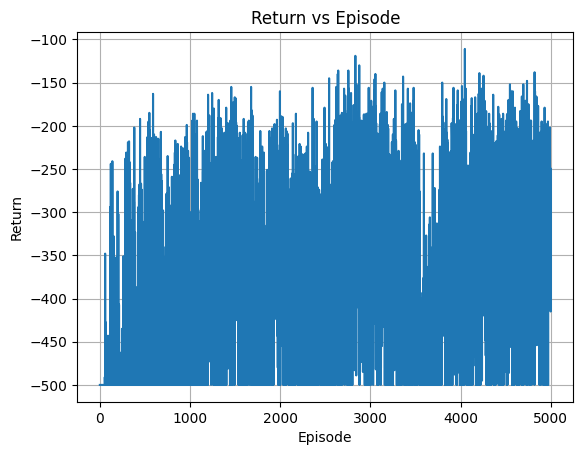

In [39]:
plot_returns(returns_sarsa_decay)

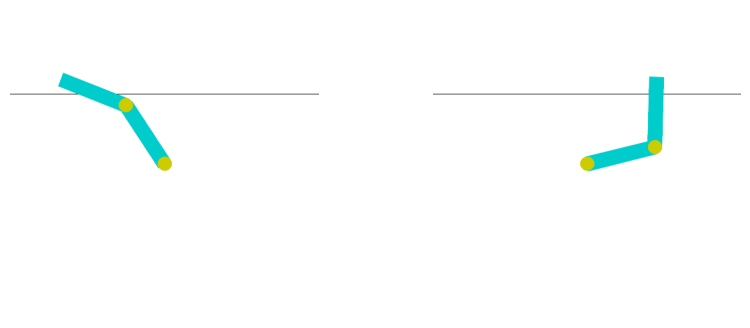

In [44]:
visualize_policy_notebook(Q_sarsa_decay, episodes=2)

In [45]:
def Q_learning_decay():
    env = gym.make("Acrobot-v1")

    # Q-table: 10^6 states × 3 actions
    Q = np.zeros((num_bins,)*6 + (3,), dtype=np.float32)

    returns = []
    epsilon = epsilon_start

    for ep in range(episodes):

        obs, _ = env.reset()
        state = discretize(obs, bins)

        action = epsilon_greedy(Q, state, epsilon)

        total_reward = 0

        for _ in range(max_steps):

            obs_next, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_next = discretize(obs_next, bins)
            action_next = epsilon_greedy(Q, state_next, epsilon)

            # SARSA update
            Q[state][action] += alpha * (reward + gamma * np.max(Q[state_next]) - Q[state][action])

            state = state_next
            action = action_next
            total_reward += reward

            if done:
                break

        returns.append(total_reward)

        # epsilon decay
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if ep % 500 == 0:
            print("Episode: ", ep)

    env.close()
    return Q, returns